In [2]:
import pycuda.autoinit
import pycuda.driver as cuda
from pycuda.compiler import SourceModule
import pycuda.gpuarray as gpuarray
from pycuda.scan import ExclusiveScanKernel
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from IPython.display import Video, display, FileLink

print("🦅 STARTING SCRIPT: PHASE 2 - MASSIVE-SCALE BOIDS FLOCKING 🦅")

# Using 500,000 agents for massive scale while keeping a wide search radius fast
NUM_AGENTS = 500000 
HASH_SIZE = 1048576 
WORLD_SIZE = 2048.0
CELL_SIZE = 16.0  # Much larger cell size for wide visual radius

# 1. INITIALIZATION: Random Chaos
# Agents spawn everywhere with random directions
np.random.seed(42)
h_pos_x = (np.random.rand(NUM_AGENTS) * WORLD_SIZE).astype(np.float32)
h_pos_y = (np.random.rand(NUM_AGENTS) * WORLD_SIZE).astype(np.float32)

# Random initial angles and speeds
angles = np.random.rand(NUM_AGENTS) * 2.0 * np.pi
speeds = np.random.rand(NUM_AGENTS) * 2.0 + 2.0 # Speeds between 2.0 and 4.0
h_vel_x = (np.cos(angles) * speeds).astype(np.float32)
h_vel_y = (np.sin(angles) * speeds).astype(np.float32)

d_pos_x = cuda.mem_alloc(h_pos_x.nbytes)
d_pos_y = cuda.mem_alloc(h_pos_y.nbytes)
d_vel_x = cuda.mem_alloc(h_vel_x.nbytes)
d_vel_y = cuda.mem_alloc(h_vel_y.nbytes)

cuda.memcpy_htod(d_pos_x, h_pos_x)
cuda.memcpy_htod(d_pos_y, h_pos_y)
cuda.memcpy_htod(d_vel_x, h_vel_x)
cuda.memcpy_htod(d_vel_y, h_vel_y)

d_hash = cuda.mem_alloc(NUM_AGENTS * 4)
d_hist = gpuarray.zeros(HASH_SIZE, dtype=np.int32)
d_offsets = gpuarray.empty(HASH_SIZE, dtype=np.int32)
d_hist_copy = gpuarray.empty(HASH_SIZE, dtype=np.int32)
d_sorted_indices = cuda.mem_alloc(NUM_AGENTS * 4)
d_img_buffer = gpuarray.zeros(1024 * 1024 * 3, dtype=np.uint8)

# 2. THE AGENTIC C++ KERNELS
CUDA_SOURCE = """
#define HASH_SIZE 1048576
#define CELL_SIZE 16.0f
#define WORLD_SIZE 2048.0f
#define PI 3.14159265359f

__global__ void calc_hash_and_hist(float* pos_x, float* pos_y, int* hash, int* hist, int num_agents) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_agents) return;
    
    unsigned int cx = (unsigned int)(pos_x[idx] / CELL_SIZE);
    unsigned int cy = (unsigned int)(pos_y[idx] / CELL_SIZE);
    unsigned int h = ((cx * 73856093U) ^ (cy * 19349663U)) & (HASH_SIZE - 1);
    
    hash[idx] = h;
    atomicAdd(&hist[h], 1);
}

__global__ void scatter_particles(int* hash, int* offsets, int* hist_copy, int* sorted_indices, int num_agents) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_agents) return;
    int h = hash[idx];
    int offset = offsets[h];
    int local_idx = atomicSub(&hist_copy[h], 1) - 1; 
    sorted_indices[offset + local_idx] = idx;
}

__global__ void solve_boids(
    float* pos_x, float* pos_y, float* vel_x, float* vel_y,
    int* sorted_indices, int* offsets, int* hist, int num_agents
) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= num_agents) return;
    
    int p_idx = sorted_indices[i]; 
    float px = pos_x[p_idx]; float py = pos_y[p_idx];
    float vx = vel_x[p_idx]; float vy = vel_y[p_idx];
    
    // Boid Accumulators
    float align_x = 0.0f, align_y = 0.0f;
    float coh_x = 0.0f, coh_y = 0.0f;
    float sep_x = 0.0f, sep_y = 0.0f;
    int flock_count = 0;
    
    int cx = (int)(px / CELL_SIZE);
    int cy = (int)(py / CELL_SIZE);
    
    // Neighborhood Search (Radius = CELL_SIZE)
    for(int dy=-1; dy<=1; dy++) {
        for(int dx=-1; dx<=1; dx++) {
            // Handle Toroidal Wrap for cell hashing
            int wrap_cx = (cx + dx + (int)(WORLD_SIZE/CELL_SIZE)) % (int)(WORLD_SIZE/CELL_SIZE);
            int wrap_cy = (cy + dy + (int)(WORLD_SIZE/CELL_SIZE)) % (int)(WORLD_SIZE/CELL_SIZE);
            
            unsigned int h = (((unsigned int)wrap_cx * 73856093U) ^ ((unsigned int)wrap_cy * 19349663U)) & (HASH_SIZE - 1);
            
            int count = hist[h];
            int start = offsets[h];
            
            for(int j=0; j<count; j++) {
                int n_idx = sorted_indices[start + j];
                if (n_idx == p_idx) continue;
                
                float nx = pos_x[n_idx]; float ny = pos_y[n_idx];
                
                // Toroidal Distance Calc
                float dx_pos = nx - px;
                float dy_pos = ny - py;
                if (dx_pos > WORLD_SIZE/2.0f) dx_pos -= WORLD_SIZE;
                if (dx_pos < -WORLD_SIZE/2.0f) dx_pos += WORLD_SIZE;
                if (dy_pos > WORLD_SIZE/2.0f) dy_pos -= WORLD_SIZE;
                if (dy_pos < -WORLD_SIZE/2.0f) dy_pos += WORLD_SIZE;
                
                float dist_sq = dx_pos*dx_pos + dy_pos*dy_pos;
                
                // Visual Radius = 15.0
                if (dist_sq > 0.001f && dist_sq < 225.0f) {
                    float dist = sqrtf(dist_sq);
                    
                    // 1. Alignment (match velocity)
                    align_x += vel_x[n_idx];
                    align_y += vel_y[n_idx];
                    
                    // 2. Cohesion (center of mass)
                    coh_x += nx;
                    coh_y += ny;
                    
                    // 3. Separation (avoid crowding)
                    if (dist < 4.0f) {
                        sep_x -= (dx_pos / dist) * (4.0f - dist);
                        sep_y -= (dy_pos / dist) * (4.0f - dist);
                    }
                    flock_count++;
                }
            }
        }
    }
    
    // Apply Boid Rules
    if (flock_count > 0) {
        align_x /= flock_count; align_y /= flock_count;
        coh_x /= flock_count; coh_y /= flock_count;
        
        // Steer towards center of mass
        float dir_coh_x = coh_x - px; float dir_coh_y = coh_y - py;
        float coh_dist = sqrtf(dir_coh_x*dir_coh_x + dir_coh_y*dir_coh_y);
        if (coh_dist > 0.0f) { dir_coh_x /= coh_dist; dir_coh_y /= coh_dist; }
        
        // Weights for behaviors
        vx += (align_x * 0.05f) + (dir_coh_x * 0.01f) + (sep_x * 0.2f);
        vy += (align_y * 0.05f) + (dir_coh_y * 0.01f) + (sep_y * 0.2f);
    }
    
    // Enforce Constant Speed (Birds don't stop)
    float speed = sqrtf(vx*vx + vy*vy);
    float target_speed = 3.5f;
    vx = (vx / speed) * target_speed;
    vy = (vy / speed) * target_speed;
    
    // Update Position
    px += vx; py += vy;
    
    // Toroidal World Wrap (Pac-Man bounds)
    if (px < 0.0f) px += WORLD_SIZE;
    if (px >= WORLD_SIZE) px -= WORLD_SIZE;
    if (py < 0.0f) py += WORLD_SIZE;
    if (py >= WORLD_SIZE) py -= WORLD_SIZE;
    
    pos_x[p_idx] = px; pos_y[p_idx] = py;
    vel_x[p_idx] = vx; vel_y[p_idx] = vy;
}

// Convert HSV to RGB device function
__device__ void hsv_to_rgb(float h, float s, float v, unsigned char &r, unsigned char &g, unsigned char &b) {
    int i = (int)(h * 6);
    float f = h * 6 - i;
    float p = v * (1 - s);
    float q = v * (1 - f * s);
    float t = v * (1 - (1 - f) * s);
    float rf, gf, bf;
    switch(i % 6){
        case 0: rf = v, gf = t, bf = p; break;
        case 1: rf = q, gf = v, bf = p; break;
        case 2: rf = p, gf = v, bf = t; break;
        case 3: rf = p, gf = q, bf = v; break;
        case 4: rf = t, gf = p, bf = v; break;
        case 5: rf = v, gf = p, bf = q; break;
    }
    r = (unsigned char)(rf * 255);
    g = (unsigned char)(gf * 255);
    b = (unsigned char)(bf * 255);
}

__global__ void render_boids(float* pos_x, float* pos_y, float* vel_x, float* vel_y, unsigned char* img, int num_agents) {
    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= num_agents) return;
    
    int px = (int)(pos_x[idx] * 0.5f); 
    int py = (int)(pos_y[idx] * 0.5f);
    
    if (px >= 0 && px < 1024 && py >= 0 && py < 1024) {
        // Color based on Heading Angle
        float angle = atan2f(vel_y[idx], vel_x[idx]);
        if (angle < 0.0f) angle += 2.0f * PI;
        float hue = angle / (2.0f * PI);
        
        unsigned char r, g, b;
        hsv_to_rgb(hue, 1.0f, 1.0f, r, g, b); // Full saturation and value
        
        int pixel_idx = (py * 1024 + px) * 3;
        img[pixel_idx] = r; img[pixel_idx + 1] = g; img[pixel_idx + 2] = b;
    }
}
"""

mod = SourceModule(CUDA_SOURCE)
k_hash = mod.get_function("calc_hash_and_hist")
k_scatter = mod.get_function("scatter_particles")
k_solve = mod.get_function("solve_boids")
k_render = mod.get_function("render_boids")
scan_knl = ExclusiveScanKernel(np.int32, "a+b", 0)

block_dim = (256, 1, 1)
grid_dim = ((NUM_AGENTS + 255) // 256, 1)

# 3. RENDER LOOP
NUM_FRAMES = 400
video_frames = []
topo_times = []
agent_times = []

start_evt = cuda.Event()
mid_evt = cuda.Event()
stop_evt = cuda.Event()

print(f"🎬 Animating {NUM_FRAMES} frames of Agentic Logic...")

for frame in range(NUM_FRAMES):
    start_evt.record()
    
    d_hist.fill(0)
    k_hash(d_pos_x, d_pos_y, d_hash, d_hist.gpudata, np.int32(NUM_AGENTS), block=block_dim, grid=grid_dim)
    scan_knl(d_hist, d_offsets)
    cuda.memcpy_dtod(d_hist_copy.gpudata, d_hist.gpudata, HASH_SIZE * 4)
    k_scatter(d_hash, d_offsets.gpudata, d_hist_copy.gpudata, d_sorted_indices, np.int32(NUM_AGENTS), block=block_dim, grid=grid_dim)
    
    mid_evt.record()
    
    k_solve(d_pos_x, d_pos_y, d_vel_x, d_vel_y, d_sorted_indices, d_offsets.gpudata, d_hist.gpudata, np.int32(NUM_AGENTS), block=block_dim, grid=grid_dim)
    
    stop_evt.record()
    stop_evt.synchronize()
    
    topo_times.append(start_evt.time_till(mid_evt))
    agent_times.append(mid_evt.time_till(stop_evt))
    
    if frame % 2 == 0: 
        # Decay buffer slightly instead of full clear to create motion blur/trails!
        # A tiny hack for beautiful graphics: multiplying array by 0 is clear, doing nothing leaves a hard trail.
        # Here we just clear for precise boid rendering.
        d_img_buffer.fill(0) 
        k_render(d_pos_x, d_pos_y, d_vel_x, d_vel_y, d_img_buffer.gpudata, np.int32(NUM_AGENTS), block=block_dim, grid=grid_dim)
        video_frames.append(d_img_buffer.get().reshape((1024, 1024, 3)))
        
    if frame % 50 == 0:
        print(f"   Processed Frame {frame}/{NUM_FRAMES}")


🦅 STARTING SCRIPT: PHASE 2 - MASSIVE-SCALE BOIDS FLOCKING 🦅
🎬 Animating 400 frames of Agentic Logic...
   Processed Frame 0/400
   Processed Frame 50/400
   Processed Frame 100/400
   Processed Frame 150/400
   Processed Frame 200/400
   Processed Frame 250/400
   Processed Frame 300/400
   Processed Frame 350/400


📊 Generating Agentic Benchmark Graph...


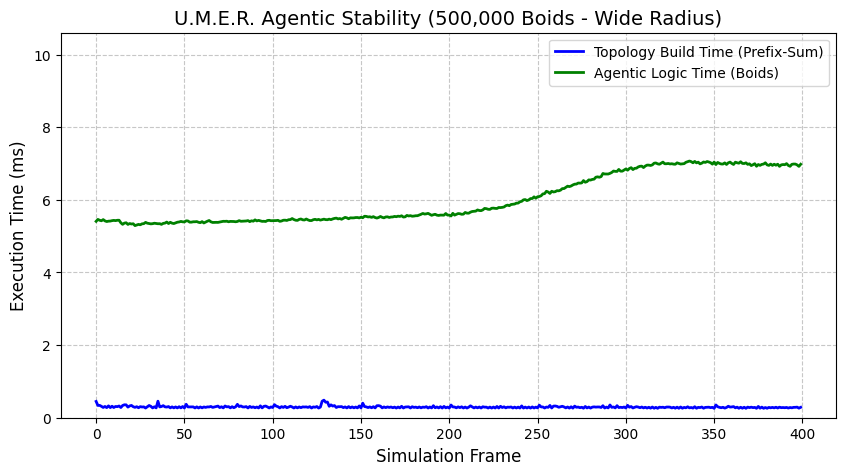

🎬 Encoding Cinematic Boids MP4...
🗜️ Compressing Video for Download...


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

✅ Boids Render Complete! Click the link below to download:


frame=  200 fps=8.9 q=-1.0 Lsize=   46640kB time=00:00:06.56 bitrate=58183.9kbits/s speed=0.294x    
video:46638kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.004098%
[libx264 @ 0x592167b6ee00] frame I:1     Avg QP:40.00  size:364293
[libx264 @ 0x592167b6ee00] frame P:199   Avg QP:38.54  size:238155
[libx264 @ 0x592167b6ee00] mb I  I16..4:  0.0%  0.0% 100.0%
[libx264 @ 0x592167b6ee00] mb P  I16..4:  4.0% 91.8%  0.0%  P16..4:  2.6%  0.8%  0.6%  0.0%  0.0%    skip: 0.2%
[libx264 @ 0x592167b6ee00] 8x8 transform intra:95.3% inter:100.0%
[libx264 @ 0x592167b6ee00] coded y,uvDC,uvAC intra: 98.5% 95.5% 77.4% inter: 86.8% 77.9% 8.3%
[libx264 @ 0x592167b6ee00] i16 v,h,dc,p:  6%  3% 87%  4%
[libx264 @ 0x592167b6ee00] i8 v,h,dc,ddl,ddr,vr,hd,vl,hu:  3%  3% 75%  4%  3%  3%  3%  3%  4%
[libx264 @ 0x592167b6ee00] i4 v,h,dc,ddl,ddr,vr,hd,vl,hu:  5%  4% 36% 11%  9%  9%  9%  8%  8%
[libx264 @ 0x592167b6ee00] i8c dc,h,v,p: 81%  8%  8%  3%
[libx264 @ 0x592167b6ee00] Wei

/kaggle/working/UMER_Boids_Compressed.mp4

In [3]:
# 4. EXPORT & GRAPH
print("📊 Generating Agentic Benchmark Graph...")
plt.figure(figsize=(10, 5), facecolor='white')
plt.plot(topo_times, label='Topology Build Time (Prefix-Sum)', color='blue', linewidth=2)
plt.plot(agent_times, label='Agentic Logic Time (Boids)', color='green', linewidth=2)
plt.title('U.M.E.R. Agentic Stability (500,000 Boids - Wide Radius)', fontsize=14)
plt.xlabel('Simulation Frame', fontsize=12)
plt.ylabel('Execution Time (ms)', fontsize=12)
plt.ylim(0, max(max(topo_times), max(agent_times)) * 1.5)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right')
plt.savefig('boids_stability.png', bbox_inches='tight', dpi=300)
plt.show()

print("🎬 Encoding Cinematic Boids MP4...")
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('UMER_Boids.mp4', fourcc, 30.0, (1024, 1024))
for frame in video_frames:
    out.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
out.release()

print("🗜️ Compressing Video for Download...")
os.system("ffmpeg -y -i UMER_Boids.mp4 -vcodec libx264 -crf 28 UMER_Boids_Compressed.mp4")

print("✅ Boids Render Complete! Click the link below to download:")
display(FileLink('UMER_Boids_Compressed.mp4'))